# StatQuest 词嵌入网络：匀速均匀分布初始化与 2D 散点图可视化

本 Notebook 复现 StatQuest 经典视频中的词嵌入演变过程：
- 词表：`['troll2', 'is', 'great!', 'Gymkata']`
- 训练数据：
  - 句子 1：`troll2 -> is -> great!`
  - 句子 2：`Gymkata -> is -> great!`
- **权重初始化**：在 `[-0.5, 0.5]` 之间均匀分布初始化 (`Uniform(-0.5, 0.5)`)
- **现象验证**：训练前 `troll2` 和 `Gymkata` 的 2D 词嵌入位置距离较远；训练后，由于它们在上下文中的语义用法一致，两个词在 2D 散点图中的位置几乎完全重合！

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -------------------------------------------------
# 0️⃣ 配置 Matplotlib 中文显示与负号显示
# -------------------------------------------------
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子以便复现图示效果
torch.manual_seed(42)

# -------------------------------------------------
# 1️⃣ 定义数据：独热编码 inputs 与 outputs
# -------------------------------------------------
words = ['troll2', 'is', 'great!', 'Gymkata']
word2idx = {w: i for i, w in enumerate(words)}
idx2word = {i: w for i, w in enumerate(words)}

# inputs 代表 troll2, is, great!, Gymkata 的独热码
inputs = torch.tensor([
    [1.0, 0.0, 0.0, 0.0],  # troll2 -> 预测 is
    [0.0, 1.0, 0.0, 0.0],  # is      -> 预测 great!
    [0.0, 0.0, 1.0, 0.0],  # great!  -> 预测 结束(<EOS>)
    [0.0, 0.0, 0.0, 1.0]   # Gymkata -> 预测 is
])

# outputs 对应按顺序预测的下一个词独热码
outputs = torch.tensor([
    [0.0, 1.0, 0.0, 0.0],  # is
    [0.0, 0.0, 1.0, 0.0],  # great!
    [0.0, 0.0, 0.0, 0.0],  # 结束/无
    [0.0, 1.0, 0.0, 0.0]   # is
])

print("inputs 形状:", inputs.shape)
print("outputs 形状:", outputs.shape)

inputs 形状: torch.Size([4, 4])
outputs 形状: torch.Size([4, 4])


In [14]:
# -------------------------------------------------
# 2️⃣ 搭建网络并使用 Uniform(-0.5, 0.5) 初始化参数
# -------------------------------------------------
class StatQuestWordEmbedding(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=2, output_dim=4):
        super().__init__()
        # 线性层 1 (4 -> 2) 对应 2维词嵌入
        self.fc1 = nn.Linear(input_dim, hidden_dim, bias=False)
        # 线性层 2 (2 -> 4) 对应 4维 Logits 输出
        self.fc2 = nn.Linear(hidden_dim, output_dim, bias=False)
        
        # 按照需求在 [-0.5, 0.5] 均匀分布初始化参数
        nn.init.uniform_(self.fc1.weight, a=-0.5, b=0.5)
        nn.init.uniform_(self.fc2.weight, a=-0.5, b=0.5)

    def forward(self, x):
        hidden = self.fc1(x)       # (batch, 2)
        logits = self.fc2(hidden)   # (batch, 4)
        return logits

model = StatQuestWordEmbedding()

# 记录训练前的 2 维词嵌入坐标 (fc1.weight 的列向量为词嵌入)
before_embeddings = model.fc1.weight.T.detach().clone().numpy()

print("--- 训练前 (Before Training) 各词的 2D 向量 ---")
for i, w in enumerate(words):
    print(f"'{w:8s}' -> [{before_embeddings[i][0]:.4f}, {before_embeddings[i][1]:.4f}]")

--- 训练前 (Before Training) 各词的 2D 向量 ---
'troll2  ' -> [0.3854, -0.2304]
'is      ' -> [0.0739, -0.0586]
'great!  ' -> [-0.2334, -0.2031]
'Gymkata ' -> [0.1274, 0.3317]


In [15]:
# -------------------------------------------------
# 3️⃣ 训练网络模型
# -------------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
criterion = nn.MSELoss()

epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    preds = model(inputs)
    loss = criterion(preds, outputs)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1:3d} | Loss: {loss.item():.6f}")

# 记录训练后的 2 维词嵌入坐标
after_embeddings = model.fc1.weight.T.detach().clone().numpy()

print("\n--- 训练后 (After Training) 各词的 2D 向量 ---")
for i, w in enumerate(words):
    print(f"'{w:8s}' -> [{after_embeddings[i][0]:.4f}, {after_embeddings[i][1]:.4f}]")

Epoch 100 | Loss: 0.000004
Epoch 200 | Loss: 0.000000
Epoch 300 | Loss: 0.000000
Epoch 400 | Loss: 0.000005
Epoch 500 | Loss: 0.000000

--- 训练后 (After Training) 各词的 2D 向量 ---
'troll2  ' -> [-0.4104, -1.3935]
'is      ' -> [0.8070, -0.0742]
'great!  ' -> [-0.0000, 0.0000]
'Gymkata ' -> [-0.4104, -1.3935]


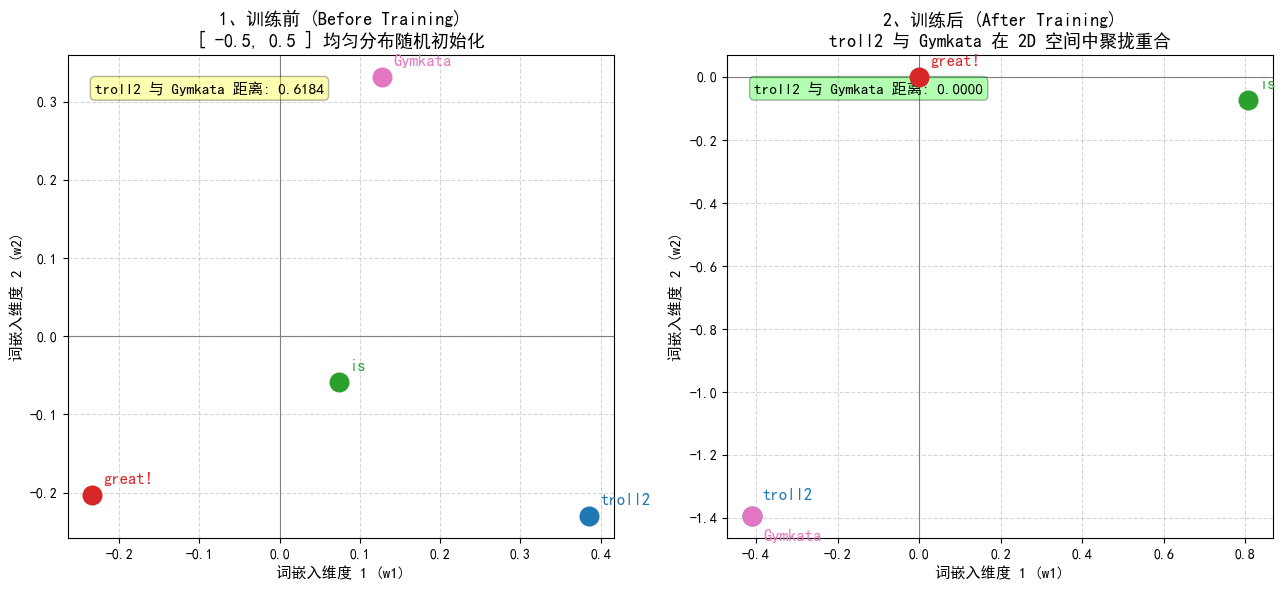

In [16]:
# -------------------------------------------------
# 4️⃣ 2D 散点图对比可视化 (支持中文无乱码显示)
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
colors = ['#1f77b4', '#2ca02c', '#d62728', '#e377c2']  # troll2, is, great!, Gymkata

# 子图 1：训练前散点图
ax1 = axes[0]
for i, word in enumerate(words):
    x, y = before_embeddings[i]
    ax1.scatter(x, y, color=colors[i], s=180, label=word, zorder=5)
    ax1.annotate(word, (x, y), xytext=(8, 8), textcoords='offset points', fontsize=12, fontweight='bold', color=colors[i])

ax1.set_title("1、训练前 (Before Training)\n[ -0.5, 0.5 ] 均匀分布随机初始化", fontsize=13)
ax1.set_xlabel("词嵌入维度 1 (w1)", fontsize=11)
ax1.set_ylabel("词嵌入维度 2 (w2)", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.axhline(0, color='gray', linewidth=0.8)
ax1.axvline(0, color='gray', linewidth=0.8)

# 计算训练前 troll2 和 Gymkata 的欧氏距离
dist_before = torch.norm(torch.tensor(before_embeddings[0]) - torch.tensor(before_embeddings[3])).item()
ax1.text(0.05, 0.92, f"troll2 与 Gymkata 距离: {dist_before:.4f}", transform=ax1.transAxes, fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))

# 子图 2：训练后散点图
ax2 = axes[1]
for i, word in enumerate(words):
    x, y = after_embeddings[i]
    ax2.scatter(x, y, color=colors[i], s=180, label=word, zorder=5)
    # 微调重合点文字位置以免重叠
    offset_y = 12 if word == 'troll2' else (-18 if word == 'Gymkata' else 8)
    ax2.annotate(word, (x, y), xytext=(8, offset_y), textcoords='offset points', fontsize=12, fontweight='bold', color=colors[i])

ax2.set_title("2、训练后 (After Training)\ntroll2 与 Gymkata 在 2D 空间中聚拢重合", fontsize=13)
ax2.set_xlabel("词嵌入维度 1 (w1)", fontsize=11)
ax2.set_ylabel("词嵌入维度 2 (w2)", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.axhline(0, color='gray', linewidth=0.8)
ax2.axvline(0, color='gray', linewidth=0.8)

# 计算训练后 troll2 和 Gymkata 的欧氏距离
dist_after = torch.norm(torch.tensor(after_embeddings[0]) - torch.tensor(after_embeddings[3])).item()
ax2.text(0.05, 0.92, f"troll2 与 Gymkata 距离: {dist_after:.4f}", transform=ax2.transAxes, fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="lime", alpha=0.3))

plt.tight_layout()
plt.show()